In [2]:
#Installing required libraries
!pip install extra-keras-datasets

In [3]:
#Importing all required libraries
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from extra_keras_datasets import emnist

In [4]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [5]:
# Loading EMNIST balanced dataset
(X_train, y_train), (X_test, y_test) = emnist.load_data(type='balanced')

print("Training images shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Test images shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

Exception: URL fetch failure on http://www.itl.nist.gov/iaui/vip/cs_links/EMNIST/matlab.zip: 403 -- Forbidden

In [9]:
#Installing TensorFlow Datasets
!pip install tensorflow-datasets

In [7]:
#Importing libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds

In [18]:
#Loading EMNIST Balanced from TFDS
(ds_train, ds_test), ds_info = tfds.load(
    "emnist/byclass",
    split=["train", "test"],
    as_supervised=True,
    with_info=True
)

print(ds_info)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/byclass/incomplete.3MV07T_3.1.0/emnist-train.tfrecord*...:   0%|   …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/byclass/incomplete.3MV07T_3.1.0/emnist-test.tfrecord*...:   0%|    …

Dataset emnist downloaded and prepared to /root/tensorflow_datasets/emnist/byclass/3.1.0. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='emnist',
    full_name='emnist/byclass/3.1.0',
    description="""
    The EMNIST dataset is a set of handwritten character digits derived from the NIST Special Database 19 and converted to a 28x28 pixel image format and dataset structure that directly matches the MNIST dataset.
    
    Note: Like the original EMNIST data, images provided here are inverted horizontally and rotated 90 anti-clockwise. You can use `tf.transpose` within `ds.map` to convert the images to a human-friendlier format.
    """,
    config_description="""
    EMNIST ByClass
    """,
    homepage='https://www.nist.gov/itl/products-and-services/emnist-dataset',
    data_dir='/root/tensorflow_datasets/emnist/byclass/3.1.0',
    file_format=tfrecord,
    download_size=535.73 MiB,
    dataset_size=349.16 MiB,
    features=FeaturesDict({
        'image': Imag

In [19]:
#Converting dataset to NumPy (for easy ML work)
def ds_to_numpy(dataset):
    images, labels = [], []
    for img, lab in tfds.as_numpy(dataset):
        images.append(img)
        labels.append(lab)
    return np.array(images), np.array(labels)

X_train, y_train = ds_to_numpy(ds_train)
X_test, y_test = ds_to_numpy(ds_test)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (697932, 28, 28, 1) (697932,)
Test : (116323, 28, 28, 1) (116323,)


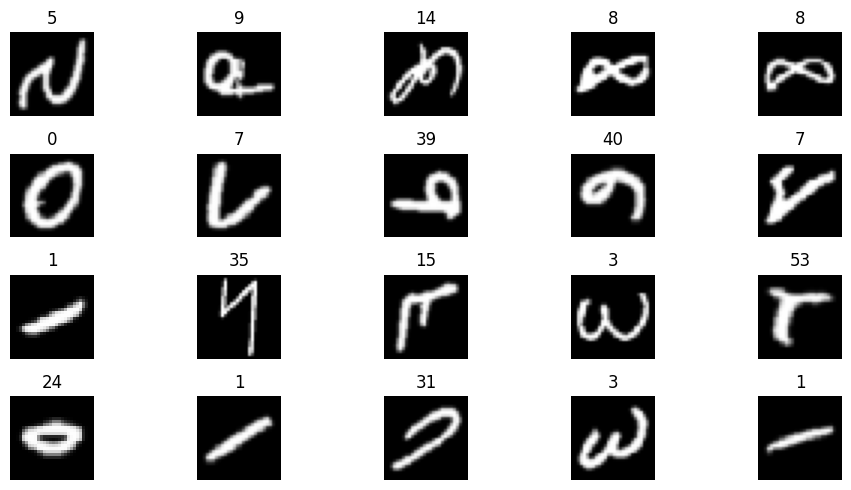

In [20]:
#Visualizing handwritten samples
plt.figure(figsize=(10,5))

for i in range(20):
    plt.subplot(4,5,i+1)
    plt.imshow(X_train[i].squeeze(), cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [21]:
#Checking current image shape
print("Original shape:", X_train.shape)
print("Example image shape:", X_train[0].shape)

Original shape: (697932, 28, 28, 1)
Example image shape: (28, 28, 1)


In [25]:
#Normalizing pixel values
X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

print("Pixel range:", X_train.min(), "to", X_train.max())

Pixel range: 0.0 to 0.003921569


In [26]:
if len(X_train.shape) == 3:
    X_train = np.expand_dims(X_train, axis=-1)
    X_test  = np.expand_dims(X_test, axis=-1)

print("CNN input shape:", X_train.shape)

CNN input shape: (697932, 28, 28, 1)


In [24]:
print("Min label:", y_train.min())
print("Max label:", y_train.max())
print("Unique classes:", len(np.unique(y_train)))

Min label: 0
Max label: 61
Unique classes: 62


In [ ]:
#One-hot encode labels for 62 classes
num_classes = 62

y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes)
y_test_cat  = tf.keras.utils.to_categorical(y_test, num_classes)

print("One-hot label shape:", y_train_cat.shape)

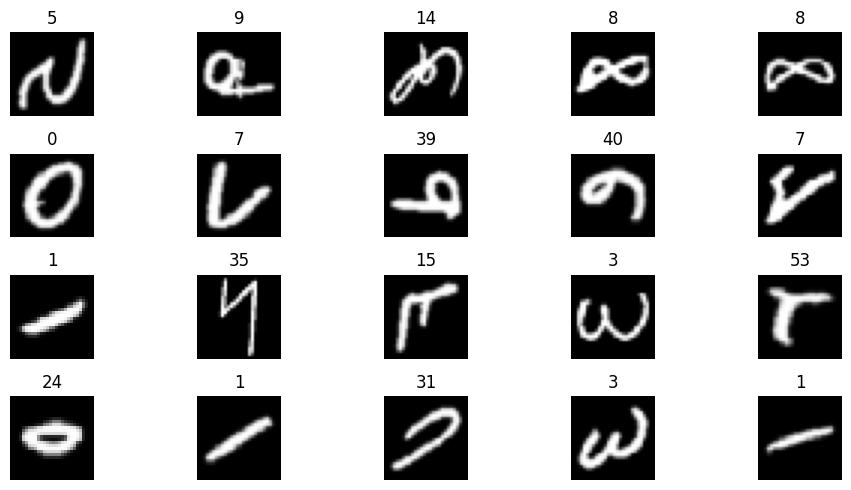

In [27]:
#Visual Confirmation
plt.figure(figsize=(10,5))

for i in range(20):
    plt.subplot(4,5,i+1)
    plt.imshow(X_train[i].squeeze(), cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [28]:
#Importing required Keras layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [30]:
#Defining the CNN architecture
model = Sequential([

    # First Convolution Block
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    # Second Convolution Block
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    # Convert feature maps to vector
    Flatten(),

    # Fully connected layer
    Dense(128, activation='relu'),
    Dropout(0.3),

    # Output layer for 62 classes
    Dense(62, activation='softmax')
])

In [31]:
#Compiling the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [32]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 62)             │         7,998 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 231,742 (905.24 KB)

 Trainable params: 231,742 (905.24 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
num_classes = 62

y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes)
y_test_cat  = tf.keras.utils.to_categorical(y_test, num_classes)

print("One-hot shapes:", y_train_cat.shape, y_test_cat.shape)

One-hot shapes: (697932, 62) (116323, 62)


In [35]:
#Start training
history = model.fit(
    X_train, y_train_cat,
    epochs=5,
    batch_size=128,
    validation_data=(X_test, y_test_cat)
)

Epoch 1/5
5453/5453 ━━━━━━━━━━━━━━━━━━━━ 510s 93ms/step - accuracy: 0.4177 - loss: 2.1953 - val_accuracy: 0.7888 - val_loss: 0.6410
Epoch 2/5
5453/5453 ━━━━━━━━━━━━━━━━━━━━ 520s 95ms/step - accuracy: 0.7542 - loss: 0.7741 - val_accuracy: 0.8150 - val_loss: 0.5458
Epoch 3/5
5453/5453 ━━━━━━━━━━━━━━━━━━━━ 519s 95ms/step - accuracy: 0.7796 - loss: 0.6807 - val_accuracy: 0.8224 - val_loss: 0.5167
Epoch 4/5
5453/5453 ━━━━━━━━━━━━━━━━━━━━ 498s 91ms/step - accuracy: 0.7922 - loss: 0.6350 - val_accuracy: 0.8283 - val_loss: 0.4955
Epoch 5/5
5453/5453 ━━━━━━━━━━━━━━━━━━━━ 496s 91ms/step - accuracy: 0.7988 - loss: 0.6098 - val_accuracy: 0.8340 - val_loss: 0.4782


In [36]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat)
print("Test accuracy:", test_acc)

3636/3636 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.8355 - loss: 0.4753
Test accuracy: 0.8340482711791992


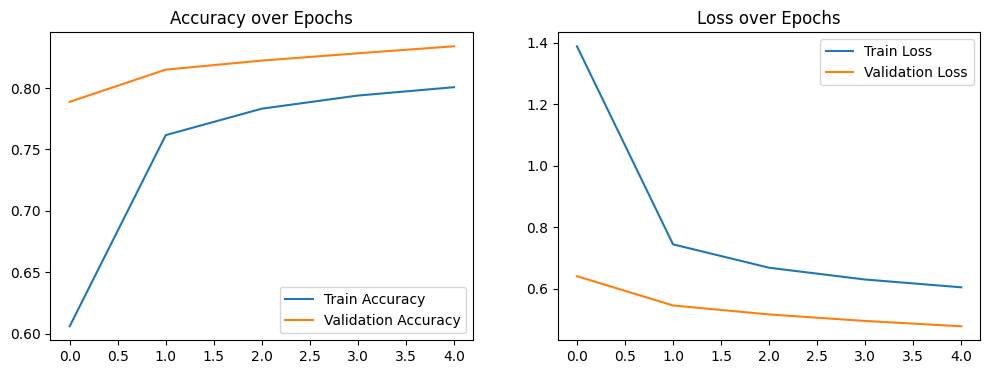

In [37]:
#Ploting training graphs
plt.figure(figsize=(12,4))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy over Epochs")

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss over Epochs")

plt.show()


In [38]:
#Getting model predictions on test data
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

3636/3636 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step


In [39]:
y_true = np.argmax(y_test_cat, axis=1)

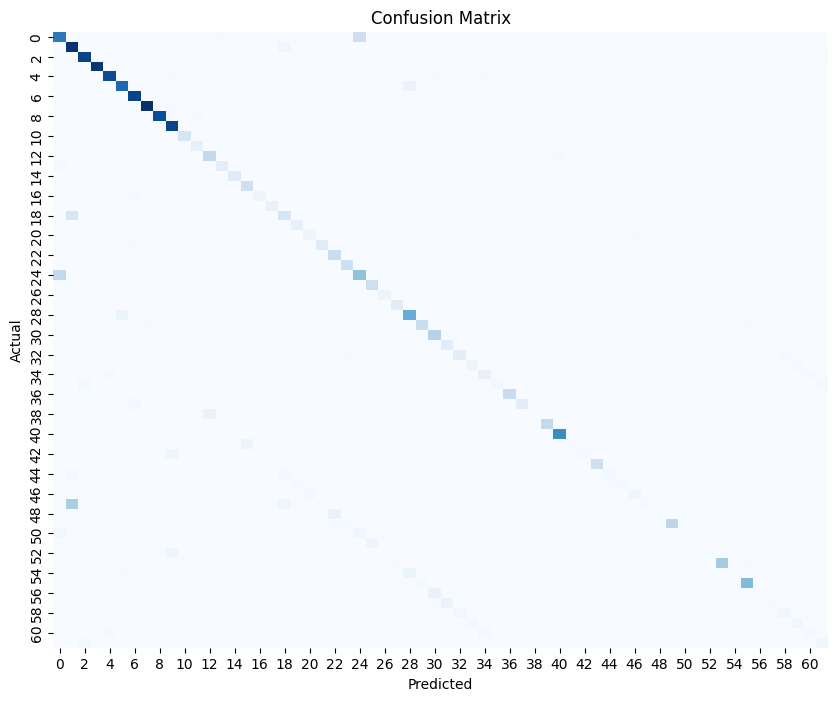

In [40]:
#Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [41]:
#Classification report (precision, recall, F1)
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.75      0.72      5778
           1       0.65      0.94      0.77      6330
           2       0.92      0.96      0.94      5869
           3       0.96      0.99      0.97      5969
           4       0.93      0.96      0.95      5619
           5       0.91      0.91      0.91      5190
           6       0.92      0.98      0.95      5705
           7       0.97      0.99      0.98      6139
           8       0.95      0.95      0.95      5633
           9       0.88      0.98      0.93      5686
          10       0.90      0.92      0.91      1062
          11       0.80      0.84      0.82       648
          12       0.75      0.90      0.82      1739
          13       0.89      0.79      0.84       779
          14       0.93      0.88      0.90       851
          15       0.76      0.88      0.82      1440
          16       0.88      0.71      0.78       447
          17       0.91    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


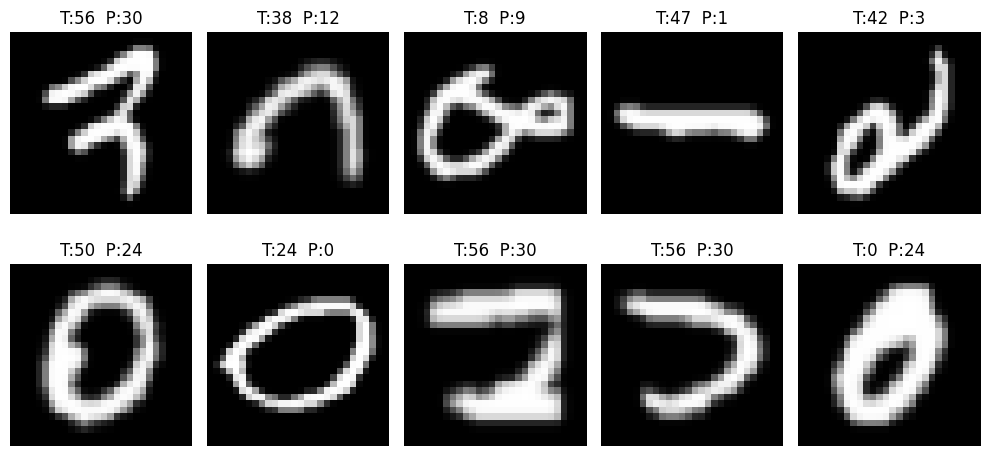

In [42]:
#Wrong predictions
plt.figure(figsize=(10,5))

wrong = np.where(y_pred != y_true)[0][:10]

for i, idx in enumerate(wrong):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[idx].squeeze(), cmap="gray")
    plt.title(f"T:{y_true[idx]}  P:{y_pred[idx]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [125]:
#Testing on Hand-written image
from google.colab import files
uploaded = files.upload()

Saving t7.jpeg to t7 (1).jpeg


In [126]:
#Preprocessing uploaded image
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = Image.open("t7.jpeg").convert("L")   # convert to grayscale
img = img.resize((28, 28))                  # resize to EMNIST size

img_array = np.array(img)

# Invert colors if background is white
img_array = 255 - img_array

# Normalize
img_array = img_array.astype("float32") / 255.0

# Reshape for CNN
img_array = np.expand_dims(img_array, axis=(0, -1))

print("Input shape:", img_array.shape)

Input shape: (1, 28, 28, 1)


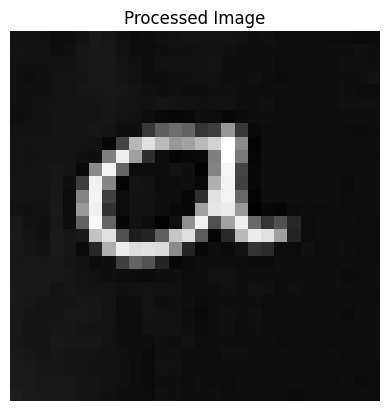

In [127]:
#Show processed image
plt.imshow(img_array[0].squeeze(), cmap="gray")
plt.title("Processed Image")
plt.axis("off")
plt.show()

In [123]:
#Predicting the character
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)

print("Predicted class index:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Predicted class index: 36


In [124]:
#Converting index to real character
def label_to_char(label):
    if 0 <= label <= 9:
        return str(label)
    elif 10 <= label <= 35:
        return chr(ord('A') + label - 10)
    else:
        return chr(ord('a') + label - 36)

print("Predicted character:", label_to_char(predicted_class))

Predicted character: a


In [129]:
model.save("handwritten_character_recognizer.keras")

In [130]:
from tensorflow.keras.models import load_model

loaded_model = load_model("handwritten_character_recognizer.keras")
print("Model loaded successfully")

Model loaded successfully


In [131]:
prediction = loaded_model.predict(X_test[:1])
print("Predicted class:", np.argmax(prediction))
print("Actual class   :", y_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
Predicted class: 24
Actual class   : 24
